# Used Car Price Prediction

## Loading the Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import GridSearchCV

sns.set_theme(style='whitegrid', palette='muted') # themes
plt.rcParams['figure.dpi'] = 110

import warnings
warnings.filterwarnings('ignore') # ignore warnings

In [2]:
df = pd.read_csv("Car details v3.csv")

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
print(f"Shape: {df.shape}")

Shape: (8128, 13)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [6]:
# Summary statistics for numerical columns
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [7]:
# Summary statistics for object/categorical columns
df.describe(include=['O'])

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,8128,8128,8128,8128,8128,7907,7907,7913,7906
unique,2058,4,3,2,5,393,121,322,441
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,129,4402,6766,7078,5289,225,1017,377,530


In [8]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [9]:
# Check unique value counts — helps identify high-cardinality columns
# Columns with very high nunique (like 'name') are likely IDs or free text
df.nunique().sort_values(ascending=False)

name             2058
km_driven         921
selling_price     677
torque            441
mileage           393
max_power         322
engine            121
year               29
seats               9
owner               5
fuel                4
seller_type         3
transmission        2
dtype: int64

## Simple EDA

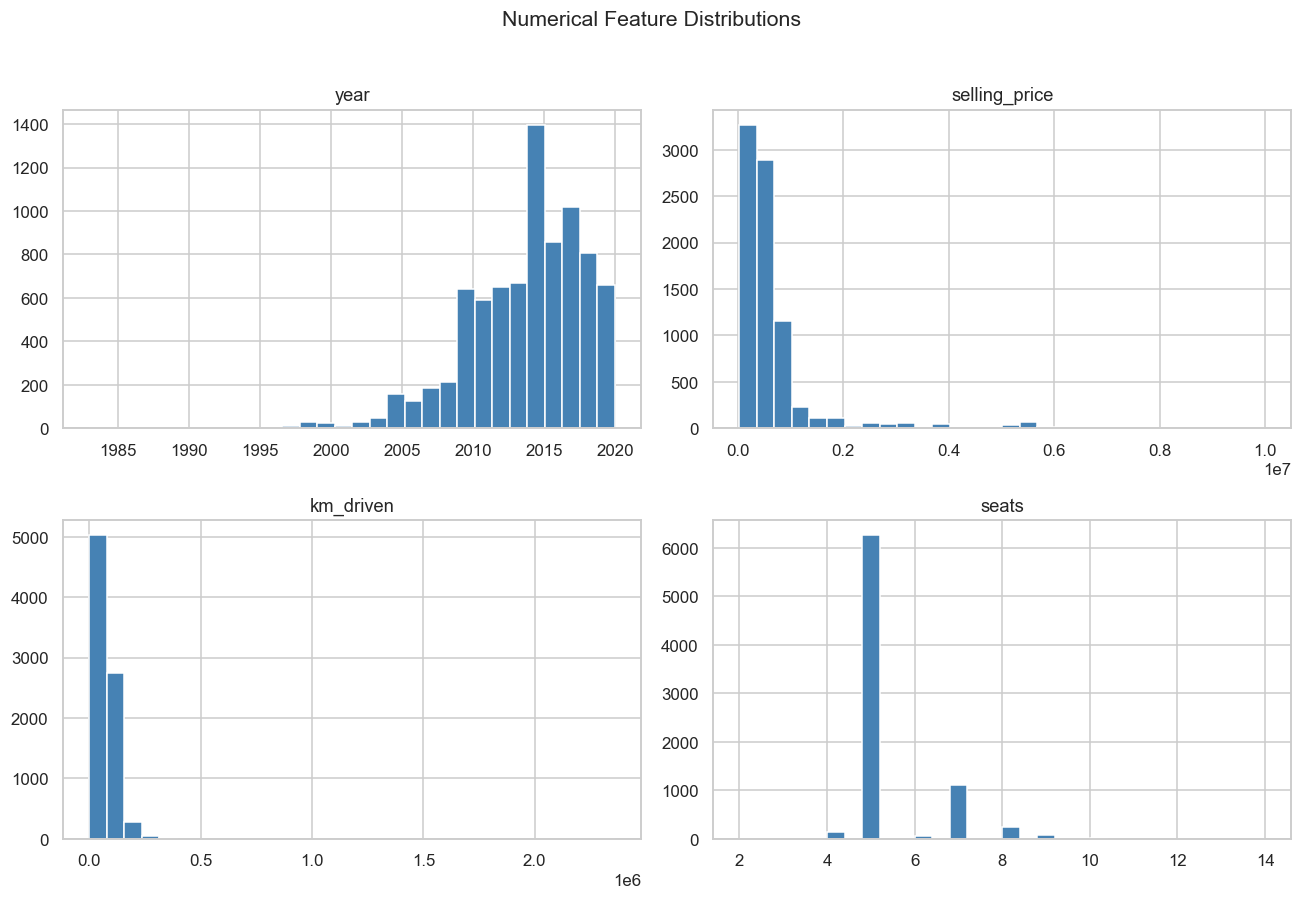

In [10]:
df.hist(figsize=(12, 8), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

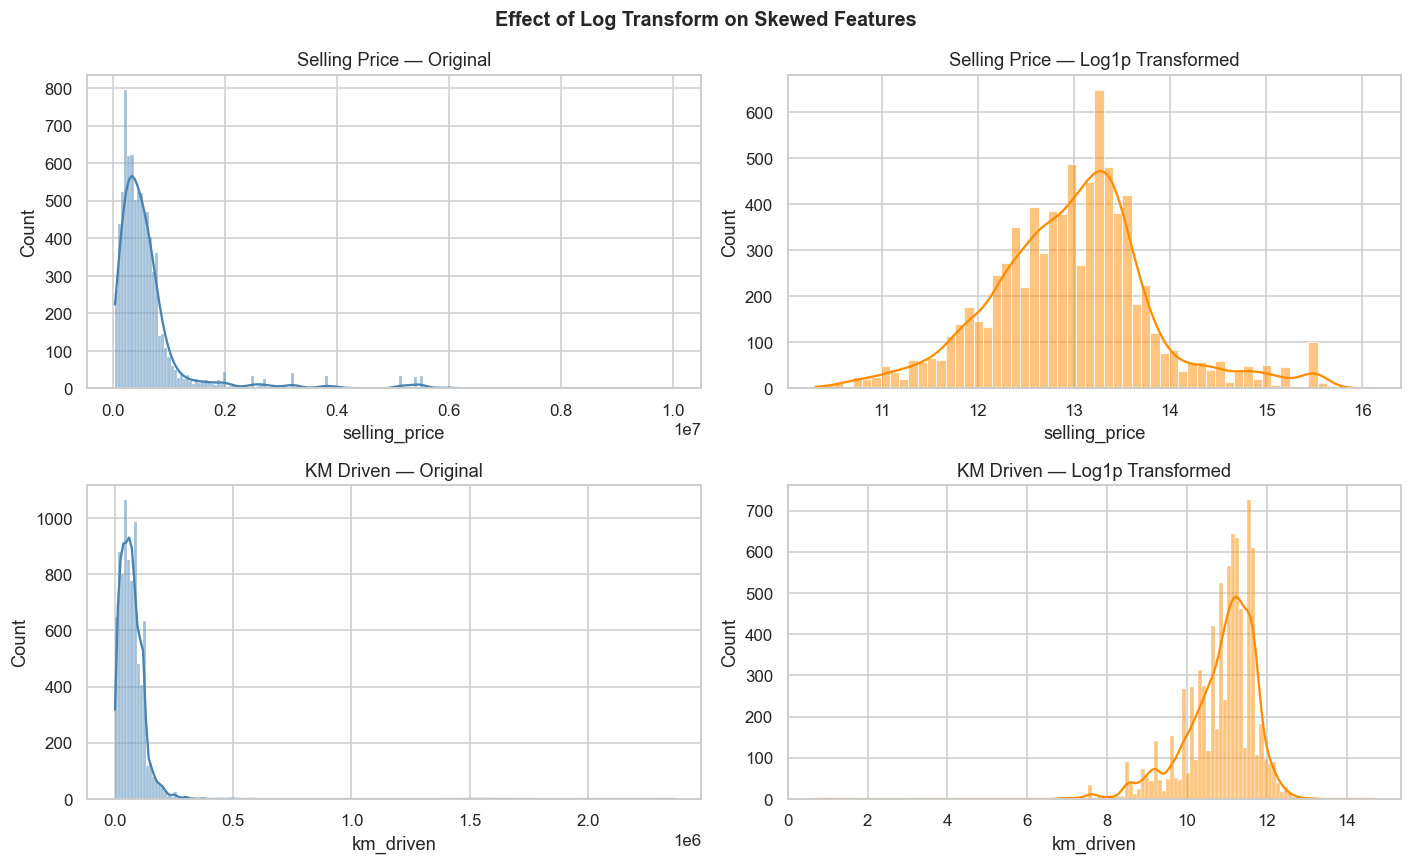

In [11]:
# Visualise the effect of log transform on both features
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df['selling_price'],     kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title(f"Selling Price — Original")

sns.histplot(np.log1p(df['selling_price']), kde=True, ax=axes[0,1], color='darkorange')
axes[0,1].set_title(f"Selling Price — Log1p Transformed")

sns.histplot(df['km_driven'],         kde=True, ax=axes[1,0], color='steelblue')
axes[1,0].set_title(f"KM Driven — Original")

sns.histplot(np.log1p(df['km_driven']),     kde=True, ax=axes[1,1], color='darkorange')
axes[1,1].set_title(f"KM Driven — Log1p Transformed")

plt.suptitle('Effect of Log Transform on Skewed Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

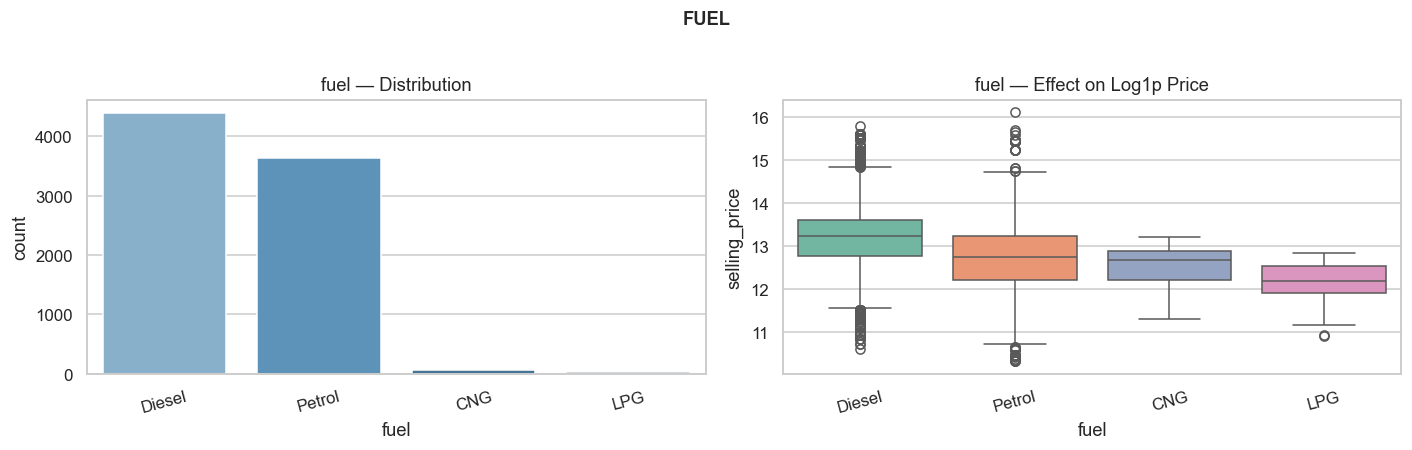

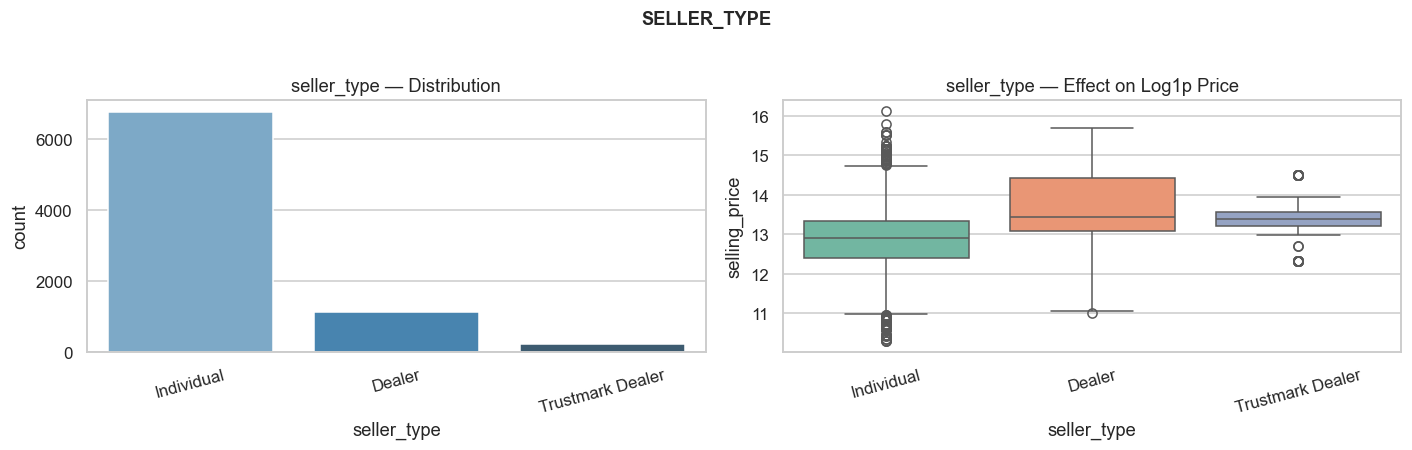

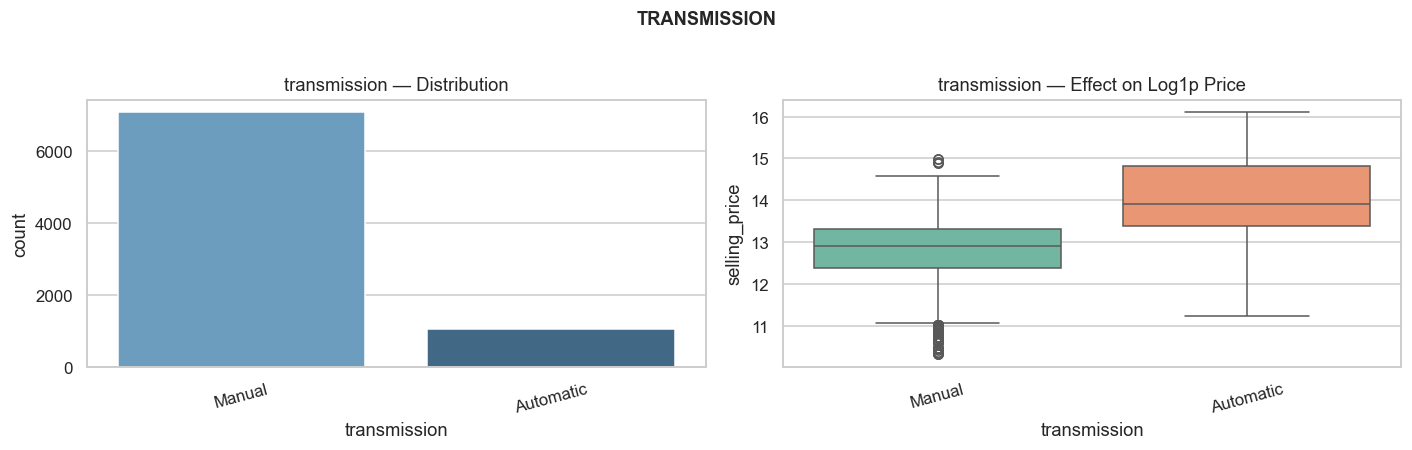

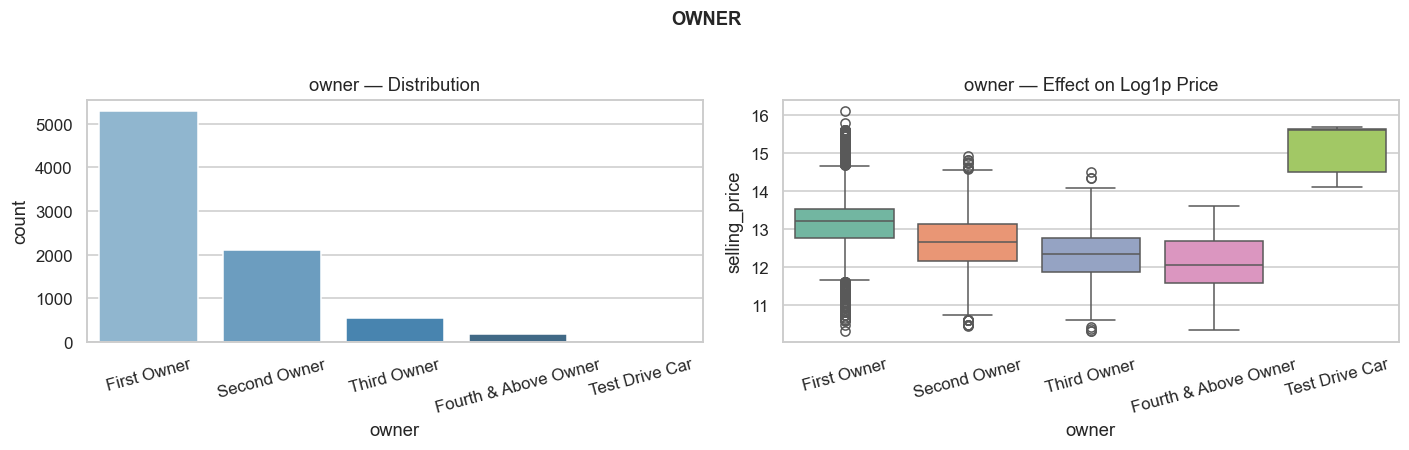

In [12]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='Blues_d', ax=axes[0])
    axes[0].set_title(f'{col} — Distribution')
    axes[0].tick_params(axis='x', rotation=15)

    sns.boxplot(data=df, x=col, y=np.log1p(df['selling_price']),
                order=order, palette='Set2', ax=axes[1])
    axes[1].set_title(f'{col} — Effect on Log1p Price')
    axes[1].tick_params(axis='x', rotation=15)

    plt.suptitle(col.upper(), fontweight='bold', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

## Data Preprocessing

In [13]:
# This dataset has a small number of missing values (<5%) — safe to drop rows
df = df.dropna()
print(f"Shape after dropping nulls: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Shape after dropping nulls: (7906, 13)
Remaining nulls: 0


In [14]:
# Apply Log1p transform to skewed features
df['log_selling_price'] = np.log1p(df['selling_price'])
df['log_km_driven']     = np.log1p(df['km_driven'])

# Convert year to car_age — more meaningful for modeling
df['car_age'] = 2026 - df['year']

In [15]:
# Drop original columns replaced by engineered versions
df.drop(columns=['selling_price', 'km_driven', 'year'], inplace=True)

print("Remaining columns:")
print(df.dtypes)

Remaining columns:
name                     str
fuel                     str
seller_type              str
transmission             str
owner                    str
mileage                  str
engine                   str
max_power                str
torque                   str
seats                float64
log_selling_price    float64
log_km_driven        float64
car_age                int64
dtype: object


In [16]:
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    print(f"{col}: {df[col].unique()}")

fuel: <StringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str
seller_type: <StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str
transmission: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
owner: <StringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str


In [17]:
# Grouping rare categories of seats
print("Seats distribution before grouping:")
print(df['seats'].value_counts())
print()

def categorize_seats(val):
    if val == 5:   return '5'
    elif val == 7: return '7'
    else:          return 'Rare'

df['seats'] = df['seats'].apply(categorize_seats)
print("Seats distribution after grouping:")
print(df['seats'].value_counts())

Seats distribution before grouping:
seats
5.0     6254
7.0     1120
8.0      235
4.0      133
9.0       80
6.0       62
10.0      19
2.0        2
14.0       1
Name: count, dtype: int64

Seats distribution after grouping:
seats
5       6254
7       1120
Rare     532
Name: count, dtype: int64


In [18]:
# Ordinal encoding — only for features with a natural order
# transmission: Manual < Automatic (automatic cars are priced higher)
# owner: First Owner (0) > Second (1) > Third (2) > Fourth+ (3)
transmission_order = ['Manual', 'Automatic']
owner_order = ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner', 'Test Drive Car']

ord_encoder = OrdinalEncoder(categories=[
    transmission_order, 
    owner_order
])

cols_ord = ['transmission', 'owner']
df[cols_ord] = ord_encoder.fit_transform(df[cols_ord])

In [19]:
df.head()

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,log_selling_price,log_km_driven,car_age
0,Maruti Swift Dzire VDI,Diesel,Individual,0.0,0.0,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5,13.017005,11.887938,12
1,Skoda Rapid 1.5 TDI Ambition,Diesel,Individual,0.0,1.0,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5,12.821261,11.695255,12
2,Honda City 2017-2020 EXi,Petrol,Individual,0.0,2.0,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5,11.970357,11.849405,20
3,Hyundai i20 Sportz Diesel,Diesel,Individual,0.0,0.0,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5,12.323860,11.751950,16
4,Maruti Swift VXI BSIII,Petrol,Individual,0.0,0.0,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5,11.775297,11.695255,19


In [20]:
# One-hot encoding — for nominal features (no natural order) 
# (equivalent to sklearn's OneHotEncoder for a single dataset)
# drop_first=True avoids the dummy variable trap (multicollinearity)
df = pd.get_dummies(df, columns=['fuel', 'seller_type', 'seats'], drop_first=True, dtype=int)

In [21]:
# Extract numeric values from string columns with units
# e.g. "1248 CC" → 1248.0,  "82.85bhp" → 82.85,  "19.67 kmpl" → 19.67
df['mileage']   = df['mileage'].str.extract(r'([\d.]+)').astype(float)
df['engine']    = df['engine'].str.extract(r'([\d.]+)').astype(float)
df['max_power'] = df['max_power'].str.extract(r'([\d.]+)').astype(float)

# Drop columns we cannot use
df.drop(columns=['name', 'torque'], inplace=True)


In [22]:
df.head()

,transmission,owner,mileage,engine,max_power,log_selling_price,log_km_driven,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,seats_7,seats_Rare
0,0.0,0.0,23.40,1248.0,74.00,13.017005,11.887938,12,1,0,0,1,0,0,0
1,0.0,1.0,21.14,1498.0,103.52,12.821261,11.695255,12,1,0,0,1,0,0,0
2,0.0,2.0,17.70,1497.0,78.00,11.970357,11.849405,20,0,0,1,1,0,0,0
3,0.0,0.0,23.00,1396.0,90.00,12.323860,11.751950,16,1,0,0,1,0,0,0
4,0.0,0.0,16.10,1298.0,88.20,11.775297,11.695255,19,0,0,1,1,0,0,0


In [23]:
df.dtypes

transmission                    float64
owner                           float64
mileage                         float64
engine                          float64
max_power                       float64
log_selling_price               float64
log_km_driven                   float64
car_age                           int64
fuel_Diesel                       int64
fuel_LPG                          int64
fuel_Petrol                       int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
seats_7                           int64
seats_Rare                        int64
dtype: object

#### Train / Test Split & Feature Scaling

In [24]:
X = df.drop(columns=['log_selling_price'])
y = df['log_selling_price']

# 80% training, 20% testing — random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
cols_to_scale = ['mileage', 'engine', 'max_power', 'log_km_driven', 'car_age']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [25]:
X_train.head()

,transmission,owner,mileage,engine,max_power,log_km_driven,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,seats_7,seats_Rare
3064,0.0,0.0,-0.123214,-0.917523,-0.687326,0.225121,2.054894,0,0,1,1,0,0,0
2522,0.0,0.0,0.259743,-0.003221,-0.221194,0.695447,0.253336,1,0,0,1,0,0,0
1819,0.0,0.0,0.885731,-0.915549,-0.690117,-0.349717,-0.776125,0,0,1,1,0,0,0
6600,0.0,2.0,-0.982414,1.414639,0.789225,0.347112,-0.261394,1,0,0,1,0,1,0
7909,0.0,0.0,0.515048,0.067870,0.468235,-1.930926,-1.033490,1,0,0,1,0,0,0


## Model Selection, Implementation & Training

### Linear Regression

In [26]:
# Training Linear Regression model
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)
lin_preds = lin_reg.predict(X_train)

In [27]:
lin_preds[:5].round(2)

array([11.65, 12.86, 12.89, 13.5 , 13.78])

In [28]:
actual_lin_preds = np.expm1(lin_preds) # Predictions in actual price (INR)
actual_lin_preds[:5].round(2)

array([114171.67, 383442.41, 397687.87, 727714.83, 967103.94])

In [29]:
actual_values = np.expm1(y_train)
actual_values[:5].values

array([135000., 490000., 325000., 900000., 850000.])

In [69]:
# MAE and RMSE of the predictions made by the Linear Regression model
lin_mae = mean_absolute_error(actual_values, actual_lin_preds)
lin_rmse = np.sqrt(mean_squared_error(actual_values, actual_lin_preds))
print(f"Linear Regression MAE: {lin_mae:.2f}")
print(f"Linear Regression RMSE: {lin_rmse:.2f}")

Linear Regression MAE: 148060.93
Linear Regression RMSE: 341398.01


In [70]:
# Helpers to calculate MAE and RMSE in actual price (INR)
def mae_in_money(true, pred):
    actual_true = np.expm1(true)
    actual_pred = np.expm1(pred)
    return mean_absolute_error(actual_true, actual_pred)
    
def rmse_in_money(true, pred):
    actual_true = np.expm1(true)
    actual_pred = np.expm1(pred)
    return np.sqrt(mean_squared_error(actual_true, actual_pred))

# scorers
money_mae_scorer = make_scorer(mae_in_money, response_method="predict", greater_is_better=False)
money_rmse_scorer = make_scorer(rmse_in_money, response_method="predict", greater_is_better=False)

In [71]:
# Evaluate the Linear Regression model's performance using cross-validation.
lin_maes = -cross_val_score(lin_reg, X_train, y_train, scoring=money_mae_scorer, cv=5)
pd.Series(lin_maes).describe()

count         5.000000
mean     148891.835488
std        7173.297861
min      137594.144392
25%      147377.871455
50%      149578.956212
75%      153974.154881
max      155934.050501
dtype: float64

In [72]:
lin_rmses = -cross_val_score(lin_reg, X_train, y_train, scoring=money_rmse_scorer, cv=5)
pd.Series(lin_rmses).describe()

count         5.000000
mean     348984.181367
std       67833.561650
min      290619.646064
25%      323109.147033
50%      328384.303303
75%      336559.390848
max      466248.419588
dtype: float64

### Decision Tree Regression

In [73]:
# Training Decision Tree Regression model
tree_reg = DecisionTreeRegressor(random_state=42)

tree_reg.fit(X_train, y_train)
tree_preds = tree_reg.predict(X_train)

In [74]:
tree_preds[:5].round(2)

array([11.81, 13.1 , 12.69, 13.71, 13.65])

In [75]:
actual_tree_preds = np.expm1(tree_preds) # Predictions in actual price (INR)
actual_tree_preds[:5].round(2)

array([135000., 490000., 325000., 900000., 850000.])

In [76]:
actual_values[:5].values

array([135000., 490000., 325000., 900000., 850000.])

In [77]:
# MAE and RMSE of the predictions made by the Decision Tree Regression model
tree_mae = mean_absolute_error(actual_values, actual_tree_preds)
tree_rmse = np.sqrt(mean_squared_error(actual_values, actual_tree_preds))
print(f"Decision Tree Regression MAE: {tree_mae:.2f}")
print(f"Decision Tree Regression RMSE: {tree_rmse:.2f}")

Decision Tree Regression MAE: 3688.06
Decision Tree Regression RMSE: 15479.03


In [78]:
# Evaluate the Decision Tree Regression model's performance using cross-validation.
tree_maes = -cross_val_score(tree_reg, X_train, y_train, scoring=money_mae_scorer, cv=5)
pd.Series(tree_maes).describe()

count        5.000000
mean     85556.925762
std       5410.635019
min      78435.144875
25%      82133.539837
50%      87135.524521
75%      87593.895659
max      92486.523920
dtype: float64

In [79]:
tree_rmses = -cross_val_score(tree_reg, X_train, y_train, scoring=money_rmse_scorer, cv=5)
pd.Series(tree_rmses).describe()

count         5.000000
mean     185408.162588
std       36015.759589
min      145704.850550
25%      154991.501380
50%      195281.477345
75%      195850.267078
max      235212.716584
dtype: float64

### Random Forest Regression

In [44]:
# Training Random Forest Regression model
forest_reg = RandomForestRegressor(random_state=42)

forest_reg.fit(X_train, y_train)
forest_preds = forest_reg.predict(X_train)

In [80]:
forest_preds[:5].round(2)

array([11.87, 13.06, 12.69, 13.74, 13.7 ])

In [81]:
actual_forest_preds = np.expm1(forest_preds) # Predictions in actual price (INR)
actual_forest_preds[:5].round(2)

array([143269.89, 471347.72, 323360.72, 929684.14, 891805.45])

In [82]:
actual_values[:5].values

array([135000., 490000., 325000., 900000., 850000.])

In [83]:
# MAE and RMSE of the predictions made by the Random Forest Regression model
forest_mae = mean_absolute_error(actual_values, actual_forest_preds)
forest_rmse = np.sqrt(mean_squared_error(actual_values, actual_forest_preds))
print(f"Random Forest Regression MAE: {forest_mae:.2f}")
print(f"Random Forest Regression RMSE: {forest_rmse:.2f}") 

Random Forest Regression MAE: 27600.73
Random Forest Regression RMSE: 63762.53


In [84]:
# Evaluate the Random Forest Regression model's performance using cross-validation.
forest_maes = -cross_val_score(forest_reg, X_train, y_train, scoring=money_mae_scorer, cv=5)
pd.Series(forest_maes).describe()

count        5.000000
mean     72596.672466
std       4351.687777
min      65943.726465
25%      70864.003101
50%      73653.561351
75%      75754.684851
max      76767.386562
dtype: float64

In [85]:
forest_rmses = -cross_val_score(forest_reg, X_train, y_train, scoring=money_rmse_scorer, cv=5)
pd.Series(forest_rmses).describe()

count         5.000000
mean     157341.940067
std       33450.597853
min      120344.917783
25%      133111.634355
50%      152607.831776
75%      177633.779336
max      203011.537086
dtype: float64

### Hyperparameter Tuning for Random Forest Regression model

In [57]:
# Hyperparameter tuning for the Random Forest Regression model (best model so far)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': [3, 5, 8, 14],     
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    forest_reg, 
    param_grid, 
    cv=5, 
    scoring=money_rmse_scorer, # help scorer
    return_train_score=True,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,make_scorer(r...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [86]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best RMSE score: {-grid_search.best_score_}")

Best parameters: {'max_depth': None, 'max_features': 14, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best RMSE score: 156228.60130771488


##  Evaluation 

In [101]:
# Retrieve the best model to make predictions on the test set
final_model = grid_search.best_estimator_ 
final_preds = final_model.predict(X_test)

In [120]:
actual_final_preds = np.expm1(final_preds)
actual_values_test = np.expm1(y_test)

print("Predicted values:", actual_final_preds[:5].round(2))
print("Actual values:", actual_values_test[:5].values)

Predicted values: [562654.31 510774.69 151677.02 328943.98 602219.68]
Actual values: [501000. 440000. 140000. 476999. 620000.]


In [130]:
final_mae = mean_absolute_error(actual_values_test, actual_final_preds)
final_rmse = np.sqrt(mean_squared_error(actual_values_test, actual_final_preds))
print(f"Final MAE: {final_mae:.2f}")
print(f"Final RMSE: {final_rmse:.2f}")

Final MAE: 61164.24
Final RMSE: 110805.01


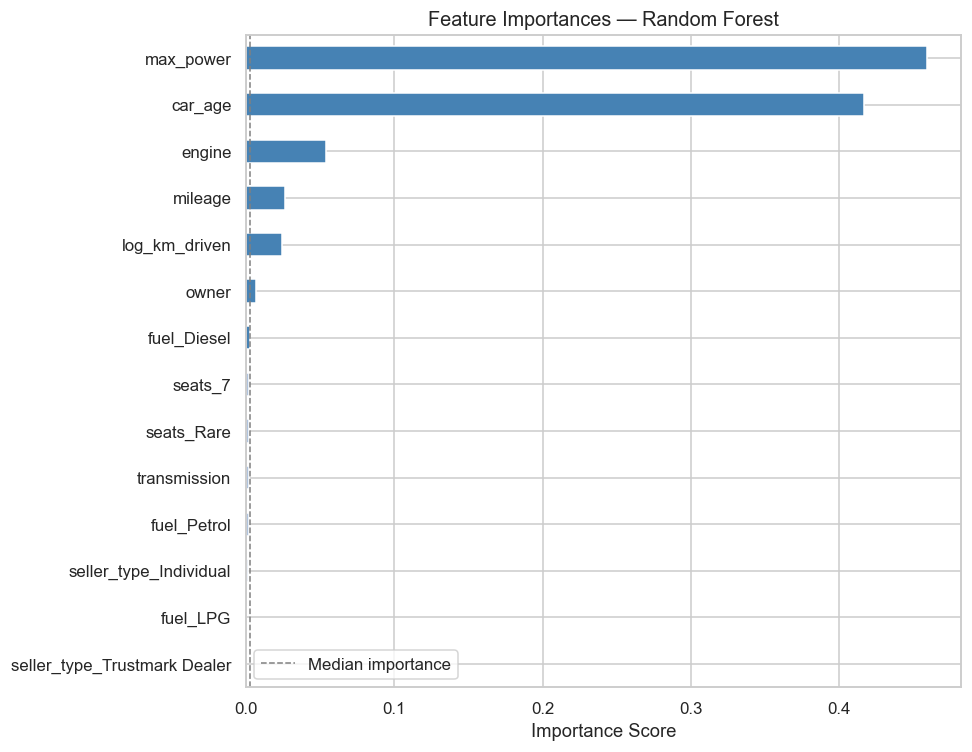

Top 5 features:
max_power        0.4593
car_age          0.4162
engine           0.0543
mileage          0.0260
log_km_driven    0.0247


In [131]:
importances = (pd.Series(final_model.feature_importances_, index=X_train.columns)
               .sort_values(ascending=True))

plt.figure(figsize=(9, 7))
colors = ['steelblue' if v > importances.median() else 'lightsteelblue'
          for v in importances.values]
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importances — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.axvline(importances.median(), color='gray', linestyle='--',
            linewidth=1, label='Median importance')
plt.legend()
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importances.sort_values(ascending=False).head().round(4).to_string())